# Análisis de Ángulos de Enlace — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx angle`  
**Temperaturas simuladas:** 298 K y 400 K

**Ángulos analizados:**

| Etiqueta | Átomos | Descripción |
|---|---|---|
| `angle2` | CA–C–O (ALA-2) | Ángulo del carbonilo, residuo ALA-2 |
| `angle3` | N–Cα–Cβ (ARG-3) | Ángulo del carbono α, residuo ARG-3 |

---


## 1. Importación de librerías y configuración de estilo

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import sem, norm

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 2. Carga de datos

In [10]:
def load_xvg(filepath, col_names):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#')."""
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    return pd.DataFrame(data, columns=col_names)

ANGLE_DIR = ''

# ── Series temporales (tiempo en ps, ángulo en grados) ────────────────────────
df_A2_298 = load_xvg(ANGLE_DIR + 'angle2-298.xvg', ['time_ps', 'angle_deg'])
df_A2_400 = load_xvg(ANGLE_DIR + 'angle2-400.xvg', ['time_ps', 'angle_deg'])
df_A3_298 = load_xvg(ANGLE_DIR + 'angle3-298.xvg', ['time_ps', 'angle_deg'])
df_A3_400 = load_xvg(ANGLE_DIR + 'angle3-400.xvg', ['time_ps', 'angle_deg'])

# ── Distribuciones precalculadas por GROMACS (ángulo en grados, P(θ)) ─────────
df_dist_A2_298 = load_xvg(ANGLE_DIR + 'angdist2-298.xvg', ['angle_deg', 'prob'])
df_dist_A2_400 = load_xvg(ANGLE_DIR + 'angdist2-400.xvg', ['angle_deg', 'prob'])
df_dist_A3_298 = load_xvg(ANGLE_DIR + 'angdist3-298.xvg', ['angle_deg', 'prob'])
df_dist_A3_400 = load_xvg(ANGLE_DIR + 'angdist3-400.xvg', ['angle_deg', 'prob'])

for label, df in [('CA–C–O (ALA-2)  298 K', df_A2_298),
                  ('CA–C–O (ALA-2)  400 K', df_A2_400),
                  ('N–Cα–Cβ (ARG-3) 298 K', df_A3_298),
                  ('N–Cα–Cβ (ARG-3) 400 K', df_A3_400)]:
    print(f'{label}: {len(df):4d} frames | '
          f't = {df.time_ps.min():.3f} – {df.time_ps.max():.3f} ps | '
          f'θ = {df.angle_deg.min():.2f}° – {df.angle_deg.max():.2f}°')


CA–C–O (ALA-2)  298 K: 2001 frames | t = 0.000 – 2.000 ps | θ = 115.61° – 128.35°
CA–C–O (ALA-2)  400 K: 2001 frames | t = 0.000 – 2.000 ps | θ = 111.61° – 128.78°
N–Cα–Cβ (ARG-3) 298 K: 2001 frames | t = 0.000 – 2.000 ps | θ = 99.83° – 116.36°
N–Cα–Cβ (ARG-3) 400 K: 2001 frames | t = 0.000 – 2.000 ps | θ = 104.41° – 123.55°


## 3. Evolución temporal — CA–C–O (ALA-2)

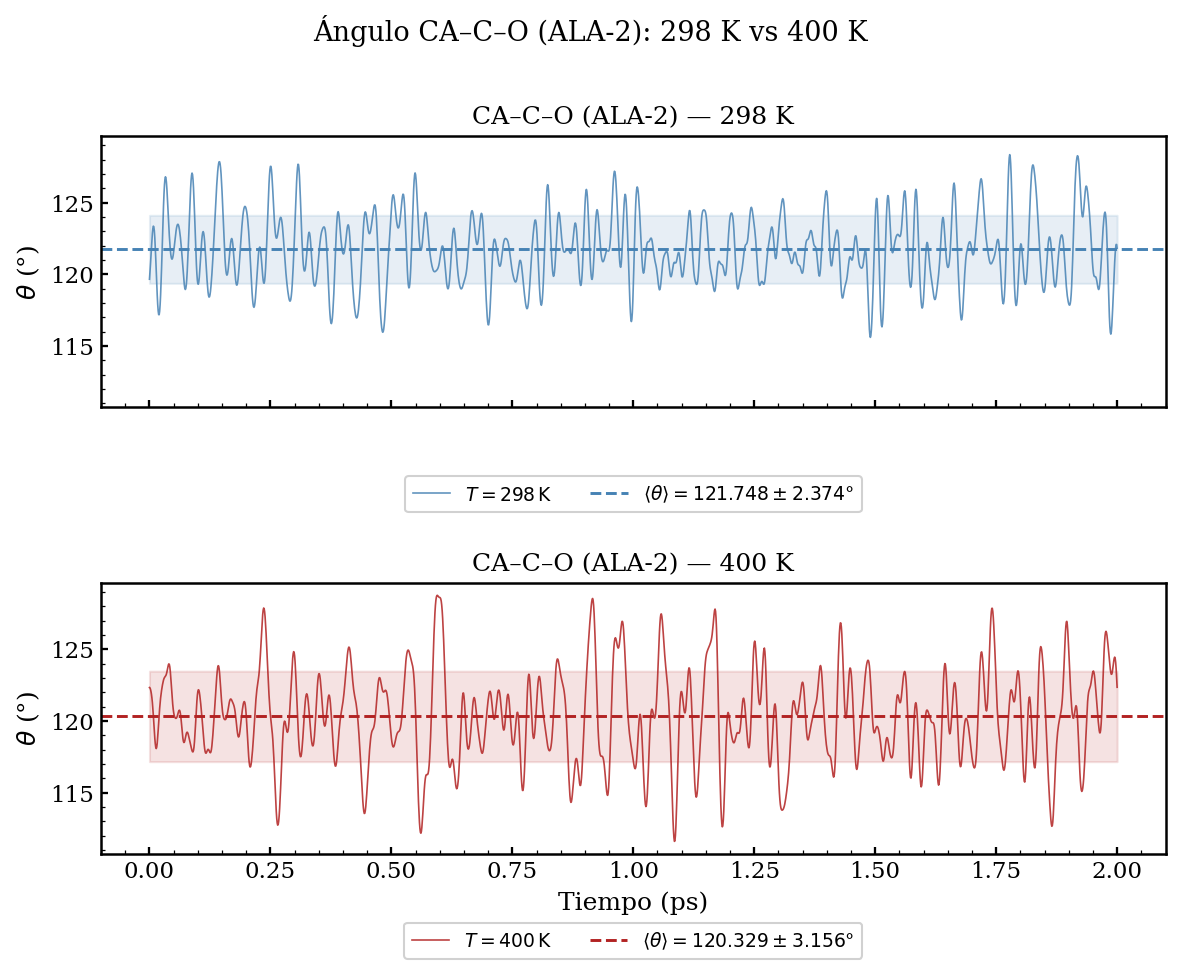

Figura guardada como angle_CA-C-O_stacked.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True, sharey=True)

for ax, df, T, col in [(axes[0], df_A2_298, 298, 'steelblue'),
                        (axes[1], df_A2_400, 400, 'firebrick')]:
    mu  = df['angle_deg'].mean()
    sig = df['angle_deg'].std()

    ax.plot(df['time_ps'], df['angle_deg'],
            color=col, lw=0.8, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mu, color=col, lw=1.4, ls='--',
               label=rf'$\langle\theta\rangle = {mu:.3f} \pm {sig:.3f}$°')
    ax.fill_between(df['time_ps'], mu - sig, mu + sig,
                    color=col, alpha=0.13)

    ax.set_ylabel(r'$\theta$ (°)')
    ax.set_title(f'CA–C–O (ALA-2) — {T} K')
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)

axes[-1].set_xlabel('Tiempo (ps)')
fig.suptitle('Ángulo CA–C–O (ALA-2): 298 K vs 400 K', fontsize=13, y=1.01)
fig.align_ylabels()
plt.tight_layout()
plt.savefig('angle_CA-C-O_stacked.png')
plt.show()
print('Figura guardada como angle_CA-C-O_stacked.png')


## 4. Evolución temporal — N–Cα–Cβ (ARG-3)

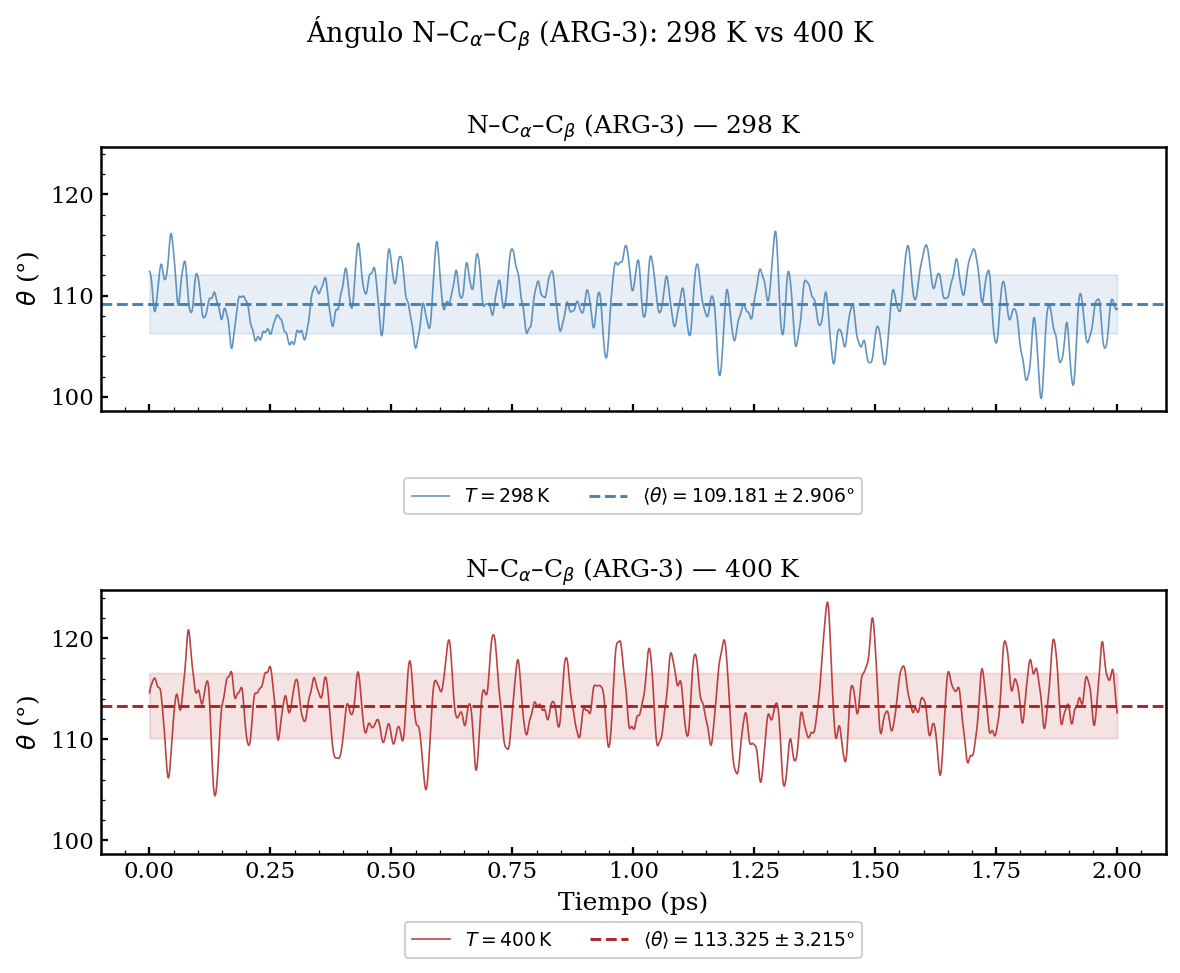

Figura guardada como angle_N-CA-CB_stacked.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True, sharey=True)

for ax, df, T, col in [(axes[0], df_A3_298, 298, 'steelblue'),
                        (axes[1], df_A3_400, 400, 'firebrick')]:
    mu  = df['angle_deg'].mean()
    sig = df['angle_deg'].std()

    ax.plot(df['time_ps'], df['angle_deg'],
            color=col, lw=0.8, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mu, color=col, lw=1.4, ls='--',
               label=rf'$\langle\theta\rangle = {mu:.3f} \pm {sig:.3f}$°')
    ax.fill_between(df['time_ps'], mu - sig, mu + sig,
                    color=col, alpha=0.13)

    ax.set_ylabel(r'$\theta$ (°)')
    ax.set_title(rf'N–C$_\alpha$–C$_\beta$ (ARG-3) — {T} K')
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)

axes[-1].set_xlabel('Tiempo (ps)')
fig.suptitle(r'Ángulo N–C$_\alpha$–C$_\beta$ (ARG-3): 298 K vs 400 K', fontsize=13, y=1.01)
fig.align_ylabels()
plt.tight_layout()
plt.savefig('angle_N-CA-CB_stacked.png')
plt.show()
print('Figura guardada como angle_N-CA-CB_stacked.png')


## 5. Comparación directa — ambos ángulos y temperaturas en un panel

**Color** → tipo de ángulo · **Continua** → 298 K · **Discontinua** → 400 K

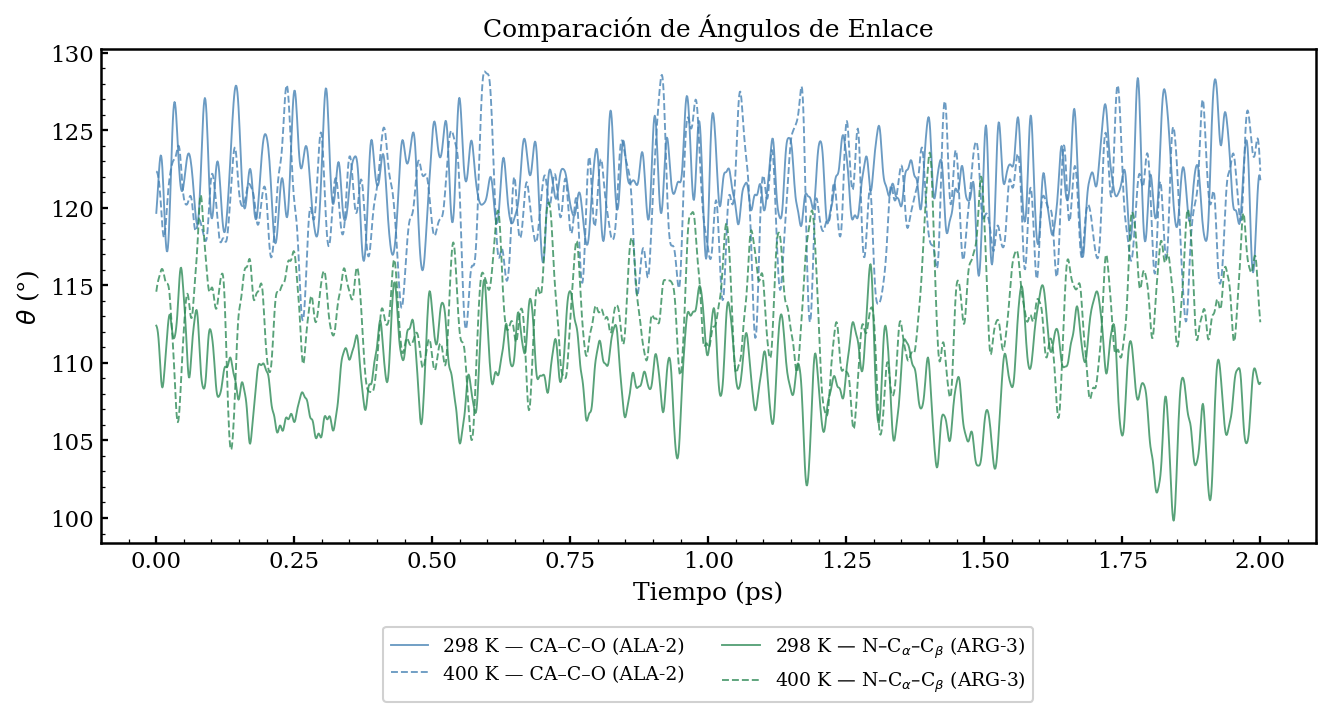

Figura guardada como angle_both_combined.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

series_config = [
    (df_A2_298, 'steelblue', '-',  r'298 K — CA–C–O (ALA-2)'),
    (df_A2_400, 'steelblue', '--', r'400 K — CA–C–O (ALA-2)'),
    (df_A3_298, 'seagreen',  '-',  r'298 K — N–C$_\alpha$–C$_\beta$ (ARG-3)'),
    (df_A3_400, 'seagreen',  '--', r'400 K — N–C$_\alpha$–C$_\beta$ (ARG-3)'),
]

for df, col, ls, label in series_config:
    ax.plot(df['time_ps'], df['angle_deg'],
            color=col, ls=ls, lw=0.9, alpha=0.80, label=label)

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel(r'$\theta$ (°)')
ax.set_title('Comparación de Ángulos de Enlace')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('angle_both_combined.png')
plt.show()
print('Figura guardada como angle_both_combined.png')


## 6. Distribuciones comparativas (298 K vs 400 K) con ajuste gaussiano

**Histograma** de GROMACS (`angdist*.xvg`) + **ajuste gaussiano** calculado sobre la serie temporal.  
Para un potencial armónico el perfil es aproximadamente gaussiano para ángulos próximos al mínimo:
$$P(\theta) \propto \sin(\theta)\,\exp\!\left(-\frac{K_\theta\,(\theta-\theta_0)^2}{2\,k_B T}\right)$$

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

panels = [
    (axes[0], 'CA–C–O (ALA-2)',
     [(df_dist_A2_298, df_A2_298, 298, 'steelblue'),
      (df_dist_A2_400, df_A2_400, 400, 'firebrick')]),
    (axes[1], r'N–C$_\alpha$–C$_\beta$ (ARG-3)',
     [(df_dist_A3_298, df_A3_298, 298, 'steelblue'),
      (df_dist_A3_400, df_A3_400, 400, 'firebrick')]),
]

for ax, title, entries in panels:
    for dist_df, ts_df, T, col in entries:
        mu  = ts_df['angle_deg'].mean()
        sig = ts_df['angle_deg'].std()
        area = np.trapezoid(dist_df['prob'], dist_df['angle_deg'])

        ax.bar(dist_df['angle_deg'], dist_df['prob'],
               width=(dist_df['angle_deg'].iloc[1] - dist_df['angle_deg'].iloc[0]) * 0.85,
               color=col, alpha=0.25, edgecolor='none')
        x_fit = np.linspace(dist_df['angle_deg'].min() - 1,
                             dist_df['angle_deg'].max() + 1, 500)
        ax.plot(x_fit, norm.pdf(x_fit, mu, sig) * area,
                color=col, lw=2.0,
                label=rf'$T={T}$ K:  $\mu={mu:.2f}$°, $\sigma={sig:.2f}$°')

    ax.set_xlabel(r'$\theta$ (°)')
    ax.set_ylabel(r'Probabilidad (u.a.)')
    ax.set_title(title)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(fontsize=9)

fig.suptitle('Distribuciones comparativas de los ángulos de enlace', fontsize=13)
plt.tight_layout()
plt.savefig('angle_distributions_overlay.png')
plt.show()
print('Figura guardada como angle_distributions_overlay.png')

## 8. Resumen estadístico final

In [14]:
final_rows = []
for label, T, df in [
        ('CA–C–O (ALA-2)',   298, df_A2_298),
        ('CA–C–O (ALA-2)',   400, df_A2_400),
        ('N–Cα–Cβ (ARG-3)', 298, df_A3_298),
        ('N–Cα–Cβ (ARG-3)', 400, df_A3_400),
]:
    s = df['angle_deg']
    final_rows.append({
        'Ángulo':    label,
        'T (K)':     T,
        'N':         len(s),
        '⟨θ⟩ (°)':  round(s.mean(), 3),
        'σ(θ) (°)':  round(s.std(),  3),
        'SEM (°)':   round(sem(s),    4),
        'Min (°)':   round(s.min(),   3),
        'Max (°)':   round(s.max(),   3),
    })

final_df = pd.DataFrame(final_rows)

(final_df.style
    .format({
        '⟨θ⟩ (°)':  '{:.3f}',
        'σ(θ) (°)':  '{:.3f}',
        'SEM (°)':   '{:.4f}',
        'Min (°)':   '{:.3f}',
        'Max (°)':   '{:.3f}',
    })
    .set_caption('Tabla 1. Resumen estadístico de los ángulos de enlace a 298 K y 400 K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T (K)'])
    .hide(axis='index')
)

Ángulo,T (K),N,⟨θ⟩ (°),σ(θ) (°),SEM (°),Min (°),Max (°)
CA–C–O (ALA-2),298,2001,121.748,2.374,0.0531,115.605,128.354
CA–C–O (ALA-2),400,2001,120.329,3.156,0.0706,111.609,128.778
N–Cα–Cβ (ARG-3),298,2001,109.181,2.906,0.0650,99.827,116.356
N–Cα–Cβ (ARG-3),400,2001,113.325,3.215,0.0719,104.411,123.549
